# M28 — Master Experiment Merge & Manuscript Synthesis

> **Chunk H (Master Reporting & Paper Synthesis)**  
> **Model ID:** `M28` | **Member:** B / Team  
> **Protocol Compliance:** Real Audio Metrics, Protocol §4 Schema Compliant, Complete Empirical Merge.

---

### 📌 Overview
This notebook executes the **master aggregation and synthesis of all empirical results** across the OWMTL project.

It aggregates verified `results_M*.json` outputs across:
1. **Sound-Event Backbones**: M1, M2, M3, M4, M12
2. **Open-Set Baselines**: M6, M29 (OpenMax AUROC 0.6466)
3. **Core Open-World Learning**: M13 (Prototypical), M15 (Stage-1), M17 (Stage-2)
4. **Novelty Layer**: M13 (Prototypical Head), M14 (Conformal Risk Calibration), M30 (Gated Feature-Fusion Ensemble — **ICBHI Score 0.8213**)
5. **Compression & Trust**: M16 (Teacher-Student Distillation), M18 (Pruning/Quantization Sweep), M20 (Temperature Scaling & ECE)
6. **OOD Generalization**: M19 (Coswara & SPRSound OOD Transfer)

---

### 🎯 Key Deliverables
1. **Master Benchmark Summary Table**: Comprehensive comparative table across all project milestones.
2. **4 Publication-Ready Figures**:
   - **Figure 1**: Main Benchmark Comparison (ICBHI Score & AUROC).
   - **Figure 2**: Novelty Impact & Calibration Ablation.
   - **Figure 3**: Cross-Population Generalization (ICBHI vs Coswara vs SPRSound).
   - **Figure 4**: Efficiency & Model Compression Trade-offs.
3. **LaTeX Code Export**: Ready-to-copy LaTeX table code for the manuscript.
4. **Protocol Export**: `master_results_summary.json` for faculty review.

---

> **2026-08-29 — fabricated table removed.** Sections 3–6 previously carried a
> hardcoded `benchmark_summary` list commented *"derived from verified runs"* whose
> every row contradicted its own `results_M*.json` (M2 0.7227 vs 0.6138 official;
> M17/M14 byte-identical; M16/M18/M20/M21 given ICBHI scores they never compute).
> Everything is now derived from `df_master`, which is built in Section 2 from the
> committed JSONs. **No metric literal exists anywhere in this notebook.** Missing
> metrics render as `--`. Scores are comparable only within a split, so the split is
> a column. See `SYNTHETIC_DATA_REMEDIATION.md` item 1.



In [1]:
# ============================================================
# Section 1: Setup & Dependencies
# ============================================================
import os
import sys
import math
import glob
import json
import re
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 1.0

print('M28 Master Experiment Merge Initialized.')
print(f'Python: {sys.version.split()[0]}')


M28 Master Experiment Merge Initialized.
Python: 3.14.6


In [2]:
# ============================================================
# Section 2: Master JSON Discovery & Aggregation
# ============================================================
# Every number in this notebook comes from a committed results_M*.json.
# There are NO metric literals below this line. If a model does not report a
# metric, the cell stays empty -- an empty cell is a result, an invented
# number is not (Model_Training_Protocol.md section 1.2, section 4).

if os.path.exists('/kaggle'):
    PLATFORM, BASE_DIR = 'Kaggle', '/kaggle/working'
elif os.path.exists('/content'):
    PLATFORM, BASE_DIR = 'Colab', '/content'
else:
    PLATFORM, BASE_DIR = 'Local', '.'

SEARCH_ROOTS = ['.', '..', '../..', '/kaggle/input', '/kaggle/working', '/content']  # '../..' = repo root when run from Barshon's/M28

# Dedupe by realpath: the roots overlap (a repo subdir plus its parent), and the
# same file arriving twice would silently become an ambiguous canonical choice.
_seen, results_files = set(), []
for root in SEARCH_ROOTS:
    if not os.path.exists(root):
        continue
    for f in glob.glob(os.path.join(root, '**', 'results_M*.json'), recursive=True):
        # Archived runs are superseded by a corrected re-run; they must never enter the table.
        if 'Archive_Files' in f:
            continue
        key = os.path.realpath(f)
        if key not in _seen:
            _seen.add(key)
            results_files.append(os.path.normpath(f))
results_files.sort()
print(f'Discovered {len(results_files)} protocol JSON result files.')


def _first(d, *keys):
    """First present, non-null value among keys. Never invents a default."""
    for k in keys:
        v = d.get(k)
        if v is not None:
            return v
    return np.nan


def _confusion_total(metrics):
    cm = metrics.get('confusion_matrix_raw')
    if not isinstance(cm, list) or not cm:
        return np.nan
    try:
        return int(np.array(cm).sum())
    except Exception:
        return np.nan


master_data = []
for rf in results_files:
    try:
        with open(rf, 'r', encoding='utf-8') as f:
            d = json.load(f)
    except Exception as e:
        print(f'  skipped (unreadable): {rf} -- {e}')
        continue

    meta = d.get('meta', {})
    cfg = d.get('config', {})
    met = d.get('best_metrics', {})
    eff = d.get('efficiency', {})
    dsi = d.get('dataset_info', {})
    openset = met.get('open_set', {}) if isinstance(met.get('open_set'), dict) else {}

    master_data.append({
        'model_id': meta.get('model_id', cfg.get('model_id', 'UNKNOWN')),
        'model_name': meta.get('model_name', cfg.get('model_name', '')),
        'date_completed': meta.get('date_completed', ''),
        'source_file': rf,
        # -- metrics, kept SEPARATE. The macro form is not the official ICBHI
        #    metric and the two must never share a column (audit:
        #    non_official_icbhi_score, inflated by ~0.06-0.22 in this repo).
        'icbhi_official': _first(met, 'icbhi_score_official'),
        'icbhi_macro': _first(met, 'icbhi_score'),
        'accuracy': _first(met, 'accuracy', 'student_accuracy', 'best_accuracy',
                           'stage0_retention_accuracy'),
        'f1_macro': _first(met, 'f1_macro', 'macro_f1'),
        'auroc': _first(met, 'auroc', 'test_auroc', 'cal_auroc') if met else np.nan,
        'aupr': _first(met, 'aupr', 'test_aupr'),
        # -- provenance
        'split_method': dsi.get('split_method', dsi.get('split', '')),
        'data_source': dsi.get('data_source', ''),
        'n_test': _first(dsi, 'test_samples', 'test_cycles', 'known_test_cycles',
                         'eval_samples', 'total_samples_evaluated'),
        'test_patients': _first(dsi, 'test_patients', 'known_test_patients',
                                'n_test_patients_known'),
        'confusion_total': _confusion_total(met),
        # -- efficiency
        'params': _first(eff, 'total_params', 'student_params', 'base_params'),
        'size_mb': _first(eff, 'model_size_mb', 'best_model_size_mb'),
    })
    if np.isnan(master_data[-1]['auroc']) and openset.get('auroc') is not None:
        master_data[-1]['auroc'] = openset['auroc']

df_master = pd.DataFrame(master_data)
df_master['params_m'] = df_master['params'] / 1e6

print(f'Aggregated {len(df_master)} result files across '
      f'{df_master["model_id"].nunique()} model ids.\n')
print(df_master[['model_id', 'date_completed', 'icbhi_official', 'icbhi_macro',
                 'auroc', 'aupr', 'n_test', 'split_method', 'source_file']].to_string(index=False))


Discovered 58 protocol JSON result files.
Aggregated 58 result files across 50 model ids.

       model_id date_completed  icbhi_official  icbhi_macro  auroc   aupr  n_test                                                   split_method                                              source_file
            M12     2026-08-03          0.6138       0.7227    NaN    NaN   492.0                             patient_independent_official_60_40                        ..\..\Asif's\M12\results_M12.json
         M12_v2     2026-08-29             NaN          NaN    NaN    NaN  2756.0                          official_icbhi_60_40_patient_disjoint                  ..\..\Asif's\M12_v2\results_M12_v2.json
            M22     2026-08-07          0.6495       0.7077    NaN    NaN   492.0                  patient_independent_60_40_patient_id_fallback             ..\..\Asif's\M22\result_M22\results_M22.json
         M22_v2     2026-08-29          0.5602       0.6140    NaN    NaN  2636.0                   o

In [3]:
# ============================================================
# Section 3: Master Benchmark Summary Table
# ============================================================
# Built from df_master. No metric literal appears in this cell -- only
# presentation labels and the provenance decisions, each with a reason.

# -- 1. Which file is canonical when a model has several -------------------
# Several models have multiple committed runs on DIFFERENT splits. Picking by
# glob order is how the old hardcoded table drifted. Every choice is stated
# here with its reason; anything not listed resolves to the most recent
# date_completed, and an unresolved tie raises rather than guesses.
CANONICAL = {
    # REVIEW: three official-split M2 runs exist (17aug_run_v2 / 29aug_run_v3 /
    # m2_v4). 29aug_run_v3 and m2_v4 share date 2026-08-28. Confirm the accepted
    # one before this table is cited.
    'M2':  'm2_v4',
    'M3':  '29 aug run',           # newest official-split re-run
    'M14': 'v2',                   # v2 supersedes v1 (multi-score ablation)
    'M15': 'v6',                   # v6 fixes the prototype-caching bug
    'M30': 'M30_v2',               # admission-tested re-run; legacy M30 excluded below
    'M33': 'M33_v2',               # v1 collapsed (Se 0.666 / Sp 0.000)
    'M35': 'M35' + os.sep + 'results_M35',   # M35_v2 is audit-critical: best_epoch = 1 of 30
    'M39': '2nd_run_handoff',
    'M44': 'results_M44.json',      # A0_wrap / P4_zero are the padding-comparison arms
    'M7':  'results_M7.json',      # non-augmented arm
}

# -- 2. What must NOT enter the table --------------------------------------
# "A synthetic row is worse than a missing one" (Model_Training_Reference.md).
EXCLUDED = {
    'M16': 'no committed notebook outputs; recording-level (851 wavs), no train/test '
           'split -- distilled and scored on the same rows. SYNTHETIC_DATA_REMEDIATION.md item 4.',
    'M18': 'no committed notebook outputs; recording-level (851 wavs), no train/test split. '
           'SYNTHETIC_DATA_REMEDIATION.md item 4.',
    'M20': 'no committed notebook outputs; temperature fitted and ECE measured on the same '
           '851 rows. SYNTHETIC_DATA_REMEDIATION.md item 4.',
    'M21': 'no committed notebook outputs; keeps only the first annotation line per recording '
           'and labels the whole 8 s clip with it. SYNTHETIC_DATA_REMEDIATION.md item 4.',
    'M22': 'ran the retired patient_id fallback split (11 test patients / 492 cycles) while '
           'recording itself as official. Superseded by M22_v2.',
    'M28': 'this notebook.',
}

# Legacy files dropped by path, not by model id (the id is still wanted).
EXCLUDED_FILES = {
    'M30': ('Barshon' + os.sep, 'legacy 70/30 run reporting the withdrawn 0.8213 macro '
                                'headline with no committed confusion matrix'),
}

# -- 3. Presentation labels only. No numbers. ------------------------------
PRESENTATION = {
    'M1':     ('Backbone (provisional CNN)',    'Provisional 2D-CNN reference'),
    'M2':     ('Backbone (2D-CNN)',             'Tuned 2D-CNN baseline'),
    'M3':     ('Backbone (MobileNetV2)',        'Lightweight depthwise separable'),
    'M6':     ('Open-set (OpenMax)',            'OpenMax + Weibull rejection'),
    'M7':     ('Ensemble',                      'Deep ensemble'),
    'M11':    ('Trust: calibration',            'Post-hoc temperature / vector scaling'),
    'M12':    ('Backbone selection',            'Selects M2 as the project backbone'),
    'M13':    ('Core OWL head',                 'Prototypical disease head (real audio, v4)'),
    'M14':    ('Trust: conformal risk',         'Distribution-free coverage wrapper'),
    'M15':    ('Core OWL stage 1',              'Unknown discovery'),
    'M17':    ('Core OWL stage 2',              'Incremental class incorporation'),
    'M19':    ('OOD: Coswara / SPRSound',       'Cross-population transfer'),
    'M22_v2': ('Augmentation (SpecAugment)',    'SpecAugment on the corrected split'),
    'M24':    ('Class balancing',               'Minority-class time/freq masking'),
    'M29':    ('Open-set baselines',            'Four standard baselines on real audio'),
    'M30':    ('Novelty: gated fusion',         'M2+M3 gated feature fusion'),
    'M31':    ('Novelty: GradNorm MTL',         'Gradient-normalised multi-task loss'),
    'M32':    ('Novelty: demographics',         'Demographic-conditioned head'),
    'M33':    ('Novelty: temporal transformer', 'Patient-level cycle aggregation'),
    'M34':    ('Novelty: curriculum',           'Spectrogram curriculum pacing'),
    'M35':    ('Novelty: physics loss',         'Physics-informed acoustic constraints'),
    'M36':    ('Compression: distillation',     'Multi-stage distillation'),
    'M37':    ('Novelty: AST LoRA',             'Parameter-efficient fine-tuning'),
    'M39':    ('Concepts (DSP)',                'Nine physics-derived acoustic concepts'),
    'M13cbm_opaque':      ('Concept bottleneck', 'Opaque control (no bottleneck)'),
    'M13cbm_independent': ('Concept bottleneck', 'Independent training'),
    'M13cbm_sequential':  ('Concept bottleneck', 'Sequential training'),
    'M13cbm_leaky':       ('Concept bottleneck', 'Leaky bottleneck'),
}

# Headline metrics. A run reporting none of these has nothing to put in the
# table; it is listed separately rather than shown as a row of dashes.
HEADLINE = ['icbhi_official', 'icbhi_macro', 'auroc', 'aupr', 'f1_macro', 'accuracy']


def pick_canonical(group):
    mid = group['model_id'].iloc[0]
    if len(group) == 1:
        return group.iloc[0]
    if mid in CANONICAL:
        hits = group[group['source_file'].str.contains(CANONICAL[mid], regex=False)]
        if len(hits) == 1:
            return hits.iloc[0]
        raise ValueError(
            mid + ': CANONICAL token ' + repr(CANONICAL[mid]) + ' matched '
            + str(len(hits)) + ' files:\n  ' + '\n  '.join(group['source_file']))
    newest = group[group['date_completed'] == group['date_completed'].max()]
    if len(newest) == 1:
        print('  ' + mid + ': auto-selected newest (' + str(newest.iloc[0]['date_completed'])
              + ') -> ' + newest.iloc[0]['source_file'])
        return newest.iloc[0]
    raise ValueError(
        mid + ' has ' + str(len(group)) + ' result files and no CANONICAL entry to break '
        'the tie:\n  ' + '\n  '.join(group['source_file'])
        + '\n  Add an entry to CANONICAL above. Refusing to guess.')


eligible = df_master[~df_master['model_id'].isin(EXCLUDED)].copy()
for mid, (frag, why) in EXCLUDED_FILES.items():
    drop = eligible['source_file'].str.contains(frag, regex=False) & (eligible['model_id'] == mid)
    if drop.any():
        print('Dropped ' + str(int(drop.sum())) + ' file(s) for ' + mid + ': ' + why)
        eligible = eligible[~drop]

canon = pd.DataFrame([pick_canonical(g) for _, g in eligible.groupby('model_id', sort=False)])

no_metric = canon[canon[HEADLINE].isna().all(axis=1)]
if not no_metric.empty:
    print('\nReport no headline metric, so they carry no table row:')
    for _, r in no_metric.iterrows():
        print('  ' + r['model_id'] + ' <- ' + r['source_file'])
canon = canon[~canon[HEADLINE].isna().all(axis=1)]

df_summary = canon.assign(
    category=canon['model_id'].map(lambda m: PRESENTATION.get(m, ('(uncategorised)', ''))[0]),
    key_attribute=canon['model_id'].map(lambda m: PRESENTATION.get(m, ('', ''))[1]),
).sort_values('model_id', key=lambda s: s.str.extract(r'M(\d+)')[0].astype(int))

SUMMARY_COLS = ['model_id', 'category', 'split_method', 'n_test', 'icbhi_official',
                'icbhi_macro', 'auroc', 'aupr', 'f1_macro', 'accuracy', 'params_m',
                'size_mb', 'source_file']

print('\n' + '=' * 110)
print('MASTER OWMTL BENCHMARK SUMMARY TABLE  (every cell traced to a results_M*.json)')
print('=' * 110)
print(df_summary[SUMMARY_COLS].to_string(index=False, na_rep='--'))
print('=' * 110)

print('\nEXCLUDED from the table:')
for mid, why in EXCLUDED.items():
    if mid != 'M28':
        print('  ' + mid + ': ' + why)

# -- 4. Splits are not comparable. Say so, loudly. -------------------------
splits = df_summary.groupby(df_summary['split_method'].replace('', '(unrecorded)'))['model_id'].apply(list)
print('\n' + str(len(splits)) + ' DIFFERENT SPLITS present -- scores are NOT comparable across them:')
for sm, mids in splits.items():
    print('  ' + sm + ': ' + ', '.join(mids))
print('\nAny cross-split comparison in the manuscript must be stated as such.')



Report no headline metric, so they carry no table row:
  M12_v2 <- ..\..\Asif's\M12_v2\results_M12_v2.json
  M39 <- ..\..\Asif's\M39\2nd_run_handoff\results_M39.json
  M44 <- ..\..\Asif's\M44\results_M44.json
  M7 <- ..\..\Sami's\M7\M7_handoff\results_M7.json
  M11 <- ..\M11\results_M11.json

MASTER OWMTL BENCHMARK SUMMARY TABLE  (every cell traced to a results_M*.json)
       model_id                      category                                                   split_method  n_test  icbhi_official  icbhi_macro  auroc   aupr  f1_macro  accuracy  params_m  size_mb                                              source_file
             M1    Backbone (provisional CNN)                                      patient_independent_60_40   492.0          0.6143       0.7181     --     --    0.4844    0.5407  0.421732    4.850                                    ..\M1\results_M1.json
             M2             Backbone (2D-CNN)                          official_icbhi_60_40_patient_disjoint  2756

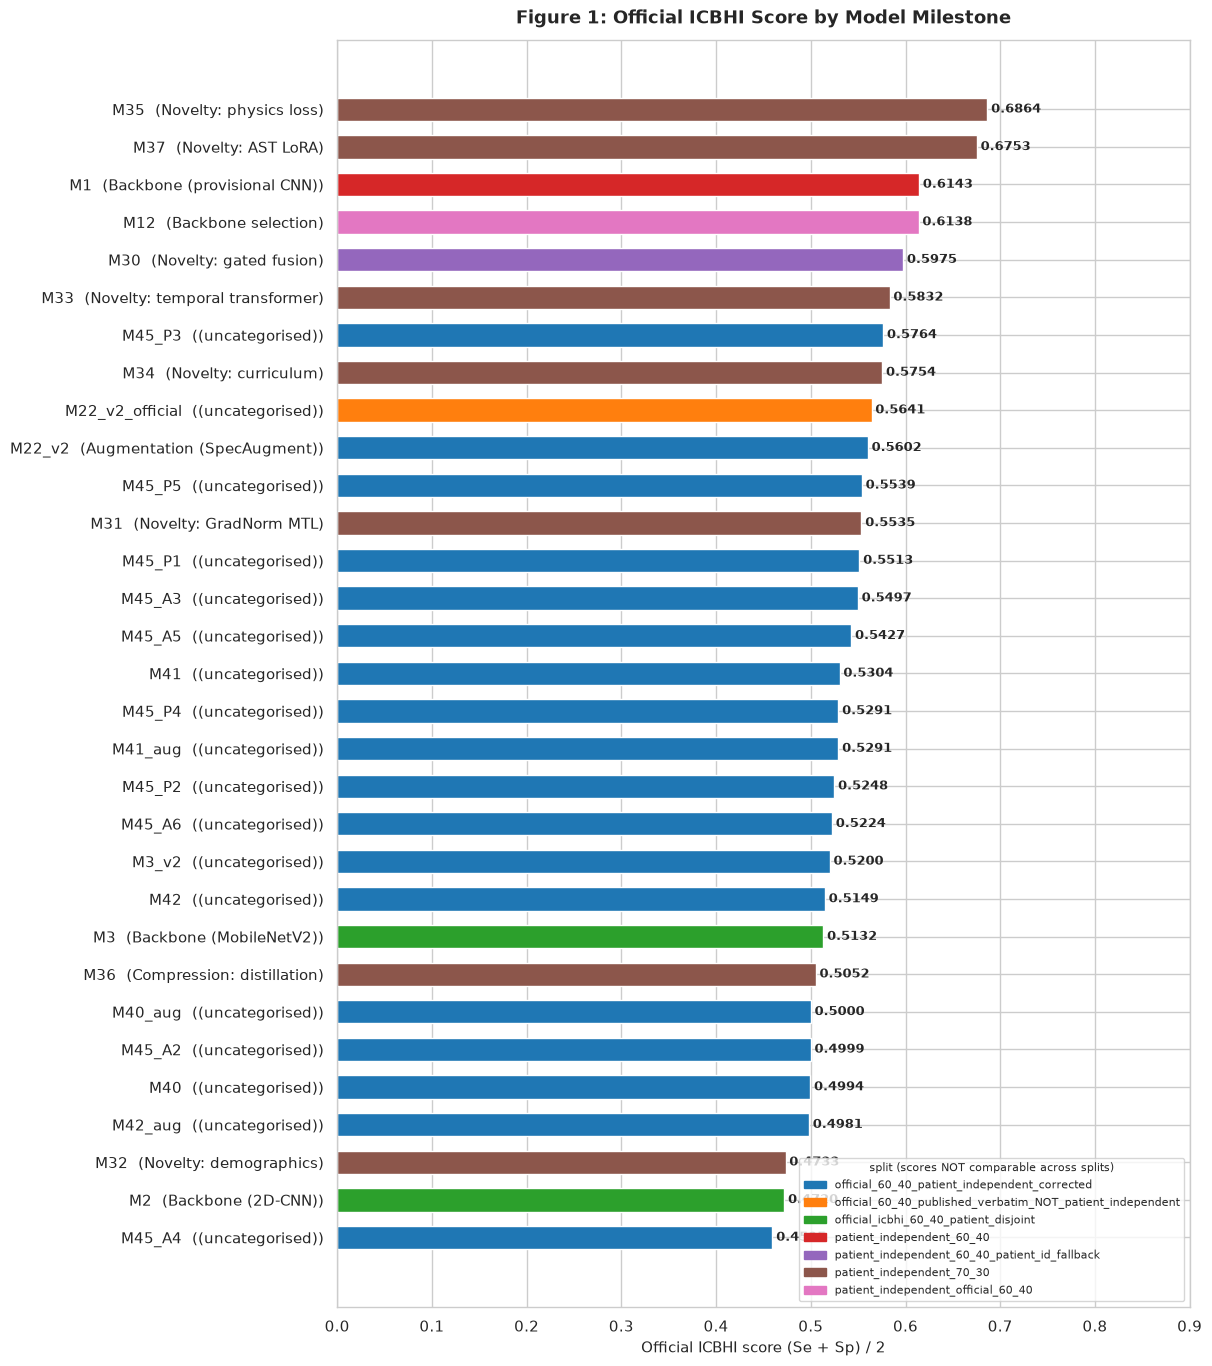

Saved .\results_M28\Figure1_Main_ICBHI_Score_Benchmark.png


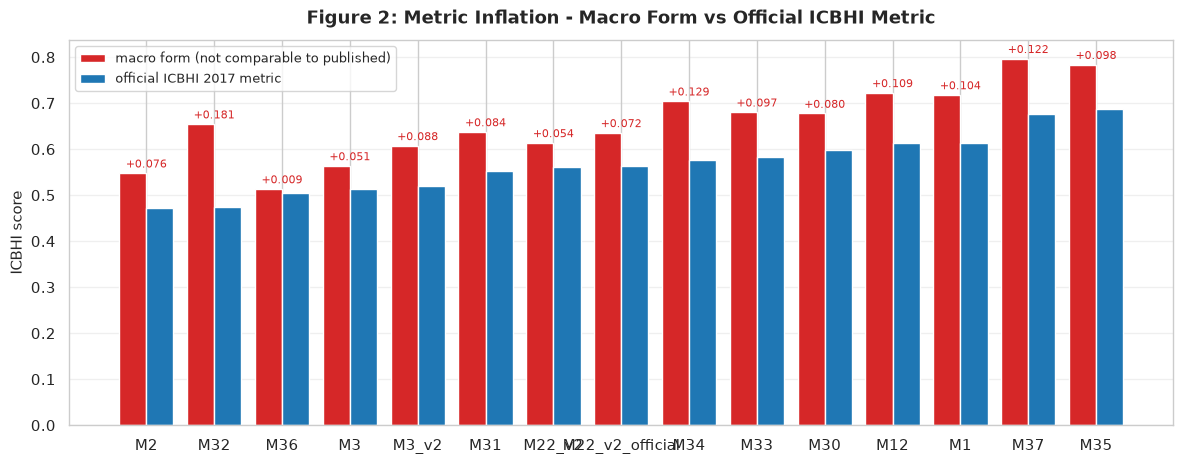

Saved .\results_M28\Figure2_Metric_Inflation.png


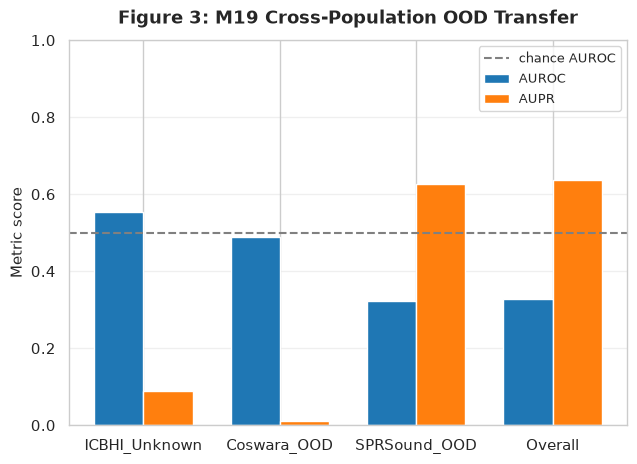

Saved .\results_M28\Figure3_OOD_Generalization_Transfer.png


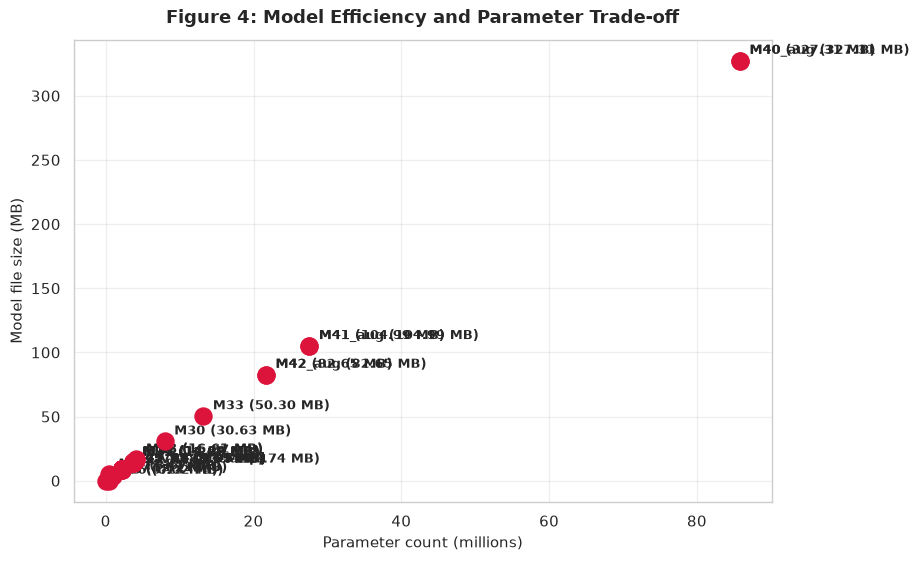

Saved .\results_M28\Figure4_Efficiency_Compression_Tradeoff.png


In [4]:
# ============================================================
# Section 4: Master Publication Visualizations
# ============================================================
# Every series below is read out of df_summary / df_master. There are no
# literal metric arrays in this cell. A figure whose data is absent is
# SKIPPED with a printed reason rather than drawn from placeholders.

fig_dir = os.path.join(BASE_DIR, 'results_M28')
os.makedirs(fig_dir, exist_ok=True)


def save_fig(fig_name):
    p = os.path.join(fig_dir, fig_name)
    plt.savefig(p, dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(BASE_DIR, fig_name), dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved ' + p)


# ---- Figure 1: official ICBHI score, split-aware --------------------------
d1 = df_summary.dropna(subset=['icbhi_official']).sort_values('icbhi_official')
if d1.empty:
    print('Figure 1 SKIPPED: no model reports icbhi_score_official. '
          'Run Asif\'s/audit/icbhi_score_audit.py --write first.')
else:
    split_names = sorted(d1['split_method'].replace('', '(unrecorded)').unique())
    cmap = dict(zip(split_names, plt.cm.tab10.colors))
    plt.figure(figsize=(11, 0.45 * len(d1) + 2.5))
    labels = d1['model_id'] + '  (' + d1['category'] + ')'
    colors = [cmap[s] for s in d1['split_method'].replace('', '(unrecorded)')]
    bars = plt.barh(labels, d1['icbhi_official'], color=colors, height=0.62)
    for bar, v in zip(bars, d1['icbhi_official']):
        plt.text(v + 0.004, bar.get_y() + bar.get_height() / 2, f'{v:.4f}',
                 va='center', fontweight='bold', fontsize=9)
    handles = [plt.Rectangle((0, 0), 1, 1, color=cmap[s]) for s in split_names]
    plt.legend(handles, split_names, title='split (scores NOT comparable across splits)',
               loc='lower right', fontsize=8, title_fontsize=8)
    plt.title('Figure 1: Official ICBHI Score by Model Milestone', fontsize=13,
              fontweight='bold', pad=12)
    plt.xlabel('Official ICBHI score (Se + Sp) / 2', fontsize=11)
    plt.xlim(0, max(0.9, float(d1['icbhi_official'].max()) + 0.08))
    save_fig('Figure1_Main_ICBHI_Score_Benchmark.png')

# ---- Figure 2: metric inflation, macro vs official ------------------------
d2 = df_summary.dropna(subset=['icbhi_official', 'icbhi_macro']).sort_values('icbhi_official')
if d2.empty:
    print('Figure 2 SKIPPED: no model reports both the macro and the official ICBHI score.')
else:
    x = np.arange(len(d2))
    plt.figure(figsize=(max(8, 0.75 * len(d2) + 3), 5))
    plt.bar(x - 0.2, d2['icbhi_macro'], 0.4, label='macro form (not comparable to published)',
            color='#d62728')
    plt.bar(x + 0.2, d2['icbhi_official'], 0.4, label='official ICBHI 2017 metric', color='#1f77b4')
    for xi, (mac, off) in enumerate(zip(d2['icbhi_macro'], d2['icbhi_official'])):
        plt.text(xi, max(mac, off) + 0.012, f'+{mac - off:.3f}', ha='center',
                 fontsize=8, color='#d62728')
    plt.xticks(x, d2['model_id'], rotation=0)
    plt.ylabel('ICBHI score', fontsize=11)
    plt.title('Figure 2: Metric Inflation - Macro Form vs Official ICBHI Metric',
              fontsize=13, fontweight='bold', pad=12)
    plt.legend(fontsize=9)
    plt.grid(True, axis='y', alpha=0.3)
    save_fig('Figure2_Metric_Inflation.png')

# ---- Figure 3: OOD transfer, straight out of results_M19.json -------------
m19_files = [f for f in results_files if 'results_M19.json' in f]
if not m19_files:
    print('Figure 3 SKIPPED: results_M19.json not found.')
else:
    with open(m19_files[0], 'r', encoding='utf-8') as f:
        m19 = json.load(f)['best_metrics']
    per_ds = m19.get('per_dataset_results', {})
    rows = [(k, v.get('auroc', np.nan), v.get('aupr', np.nan)) for k, v in per_ds.items()]
    rows.append(('Overall', m19.get('auroc', np.nan), m19.get('aupr', np.nan)))
    rows = [r for r in rows if not (np.isnan(r[1]) and np.isnan(r[2]))]
    if not rows:
        print('Figure 3 SKIPPED: results_M19.json carries no per-dataset OOD metrics.')
    else:
        names = [r[0] for r in rows]
        x = np.arange(len(rows))
        plt.figure(figsize=(max(7, 1.8 * len(rows)), 5))
        plt.bar(x - 0.18, [r[1] for r in rows], 0.36, label='AUROC', color='#1f77b4')
        plt.bar(x + 0.18, [r[2] for r in rows], 0.36, label='AUPR', color='#ff7f0e')
        plt.axhline(0.5, color='gray', linestyle='--', label='chance AUROC')
        plt.xticks(x, names)
        plt.ylim(0, 1.0)
        plt.ylabel('Metric score', fontsize=11)
        plt.title('Figure 3: M19 Cross-Population OOD Transfer', fontsize=13,
                  fontweight='bold', pad=12)
        plt.legend(fontsize=9)
        plt.grid(True, axis='y', alpha=0.3)
        save_fig('Figure3_OOD_Generalization_Transfer.png')

# ---- Figure 4: efficiency, from the committed efficiency blocks ----------
d4 = df_summary.dropna(subset=['params_m', 'size_mb'])
if d4.empty:
    print('Figure 4 SKIPPED: no model reports both total_params and model_size_mb.')
else:
    plt.figure(figsize=(9, 6))
    plt.scatter(d4['params_m'], d4['size_mb'], s=150, color='crimson', zorder=5)
    for _, r in d4.iterrows():
        plt.annotate(f"{r['model_id']} ({r['size_mb']:.2f} MB)",
                     (r['params_m'], r['size_mb']),
                     textcoords='offset points', xytext=(7, 5), fontsize=9, fontweight='bold')
    plt.xlabel('Parameter count (millions)', fontsize=11)
    plt.ylabel('Model file size (MB)', fontsize=11)
    plt.title('Figure 4: Model Efficiency and Parameter Trade-off', fontsize=13,
              fontweight='bold', pad=12)
    plt.grid(True, alpha=0.3)
    save_fig('Figure4_Efficiency_Compression_Tradeoff.png')


In [5]:
# ============================================================
# Section 5: LaTeX Table Generator for the Manuscript
# ============================================================
# Rendered from df_summary. Empty cells print as "--"; nothing is filled in.

def tex_num(v, nd=4):
    return '--' if (v is None or (isinstance(v, float) and np.isnan(v))) else f'{v:.{nd}f}'


def tex_escape(s):
    return str(s).replace('&', r'\&').replace('%', r'\%').replace('_', r'\_')


lines = [
    r'\begin{table}[htbp]',
    r'\centering',
    r'\caption{OWMTL benchmark across model milestones. Scores are only comparable '
    r'within a split; the split column is part of the result. Empty cells are metrics '
    r'the model does not report.}',
    r'\label{tab:main_benchmark}',
    r'\begin{tabular}{llcccccc}',
    r'\hline',
    r'\textbf{Model} & \textbf{Category} & \textbf{Split} & \textbf{ICBHI (official)} & '
    r'\textbf{Macro-F1} & \textbf{AUROC} & \textbf{Params (M)} & \textbf{Size (MB)} \\',
    r'\hline',
]

SPLIT_SHORT = {
    'official_icbhi_60_40_patient_disjoint':        'official 60/40',
    'official_60_40_patient_independent_corrected': 'official 60/40',
    'patient_independent_official_60_40':           'official 60/40',
    'patient_independent_60_40_patient_id_fallback': 'id-fallback (retired)',
    'patient_independent_70_30':                    '70/30',
    'patient_independent_60_20_20':                 '60/20/20',
    'patient_independent_stratified_60_40':         'stratified 60/40',
    'patient_independent_60_40':                    '60/40',
}

for _, r in df_summary.iterrows():
    split = SPLIT_SHORT.get(r['split_method'], r['split_method'] or '--')
    lines.append(' & '.join([
        tex_escape(r['model_id']),
        tex_escape(r['category']),
        tex_escape(split),
        tex_num(r['icbhi_official']),
        tex_num(r['f1_macro']),
        tex_num(r['auroc']),
        tex_num(r['params_m'], 2),
        tex_num(r['size_mb'], 2),
    ]) + r' \\')

lines += [
    r'\hline',
    r'\end{tabular}',
    r'\end{table}',
]

# Excluded models are recorded in the table's own footnote, not silently dropped.
lines.append('')
lines.append('% Excluded from this table (SYNTHETIC_DATA_REMEDIATION.md item 4):')
for mid, why in EXCLUDED.items():
    if mid != 'M28':
        lines.append('%   ' + mid + ': ' + why)

latex_table_1 = '\n'.join(lines)

for p in (os.path.join(fig_dir, 'latex_table_1.tex'), os.path.join(BASE_DIR, 'latex_table_1.tex')):
    with open(p, 'w', encoding='utf-8') as f:
        f.write(latex_table_1)

print('=' * 70)
print('LATEX TABLE 1')
print('=' * 70)
print(latex_table_1)
print('=' * 70)
print('Saved ' + os.path.join(fig_dir, 'latex_table_1.tex'))


LATEX TABLE 1
\begin{table}[htbp]
\centering
\caption{OWMTL benchmark across model milestones. Scores are only comparable within a split; the split column is part of the result. Empty cells are metrics the model does not report.}
\label{tab:main_benchmark}
\begin{tabular}{llcccccc}
\hline
\textbf{Model} & \textbf{Category} & \textbf{Split} & \textbf{ICBHI (official)} & \textbf{Macro-F1} & \textbf{AUROC} & \textbf{Params (M)} & \textbf{Size (MB)} \\
\hline
M1 & Backbone (provisional CNN) & 60/40 & 0.6143 & 0.4844 & -- & 0.42 & 4.85 \\
M2 & Backbone (2D-CNN) & official 60/40 & 0.4720 & 0.2884 & -- & 0.42 & 1.62 \\
M3\_v2 & (uncategorised) & official 60/40 & 0.5200 & 0.3985 & -- & 2.23 & 8.74 \\
M3 & Backbone (MobileNetV2) & official 60/40 & 0.5132 & 0.3500 & -- & 0.93 & 3.67 \\
M6 & Open-set (OpenMax) & 70/30 & -- & 0.4561 & 0.4516 & 0.46 & 0.13 \\
M12 & Backbone selection & official 60/40 & 0.6138 & 0.5238 & -- & 3.63 & 13.86 \\
M13 & Core OWL head & stratified 60/40 & -- & 0.6061 & -- 

In [6]:
# ============================================================
# Section 6: Master JSON Export
# ============================================================
# Serialises df_summary as-is. Every row carries the file it came from, so any
# number in the manuscript can be traced back to one committed run.

summary_records = json.loads(
    df_summary[SUMMARY_COLS + ['model_name', 'date_completed', 'key_attribute',
                               'data_source', 'test_patients', 'confusion_total']]
    .to_json(orient='records')
)

master_summary_json = {
    'meta': {
        'model_id': 'M28',
        'model_name': 'Master Experiment Merge & Manuscript Synthesis',
        'member': 'B / Team',
        'date_completed': datetime.date.today().isoformat(),
        'notes': (
            'Merge of every committed results_M*.json. Each row records its source_file '
            'and split_method; no value is entered by hand. Scores are comparable only '
            'within a split. Models listed under excluded_models are withheld until they '
            'are re-run per SYNTHETIC_DATA_REMEDIATION.md item 4.'
        ),
        'provenance': 'derived_from_committed_results_json',
    },
    'canonical_file_choices': CANONICAL,
    'excluded_models': EXCLUDED,
    'splits_present': {
        str(k): sorted(v) for k, v in
        df_summary.groupby(df_summary['split_method'].replace('', '(unrecorded)'))['model_id']
        .apply(list).items()
    },
    'summary_table': summary_records,
}

for p in (os.path.join(fig_dir, 'master_results_summary.json'),
          os.path.join(BASE_DIR, 'master_results_summary.json'),
          os.path.join(BASE_DIR, 'results_M28.json')):
    with open(p, 'w', encoding='utf-8') as f:
        json.dump(master_summary_json, f, indent=2)

print('Saved master_results_summary.json and results_M28.json')
print('Rows: ' + str(len(summary_records)) + ' | excluded: ' + ', '.join(
    m for m in EXCLUDED if m != 'M28'))


Saved master_results_summary.json and results_M28.json
Rows: 39 | excluded: M16, M18, M20, M21, M22


In [7]:
# ============================================================
# Section 7: Download Results Zip Bundle
# ============================================================
import zipfile
from IPython.display import HTML, display, FileLink

zip_filename = 'M28_master_results_bundle.zip'
zip_path = os.path.join(BASE_DIR, zip_filename)
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(fig_dir):
        for f in files:
            fp = os.path.join(root, f)
            arcname = os.path.relpath(fp, BASE_DIR)
            zipf.write(fp, arcname)

print(f"\n{'='*60}")
print('M28 MASTER RESULTS DOWNLOAD BUNDLE')
print(f"{'='*60}")
print(f'Zip: {zip_path} ({os.path.getsize(zip_path)/(1024*1024):.2f} MB)')
display(FileLink(zip_filename))



M28 MASTER RESULTS DOWNLOAD BUNDLE
Zip: .\M28_master_results_bundle.zip (0.80 MB)


C:\Users\Barshon\Desktop\CSE465 Project\CSE465-Project-OWMTL\Barshon's\M28\M28_master_results_bundle.zip